In [ ]:
# # for colab runs only
# from google.colab import drive
# drive.mount('/content/drive')
# import os
# os.chdir('/content/drive/MyDrive/nlp_project/bert_run0')

In [1]:
import sys
if 'google.colab' in sys.modules:
    from IPython.core.getipython import get_ipython
    get_ipython().run_line_magic("pip", "install transformers sentencepiece accelerate")
    #get_ipython().run_line_magic("pip", "install git+https://github.com/UlisseMini/activation_additions_hf")

In [2]:
import torch
import activation_additions as aa


import csv

import scipy.stats as stats

from typing import Dict, Union, Callable, Tuple, List
from functools import partial
from transformers import AutoModelForCausalLM, AutoTokenizer
from activation_additions.compat import get_x_vector, get_n_steered_completions, get_n_baseline_completions
from functools import lru_cache
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import PunktTokenizer
from nltk.tokenize import word_tokenize
from tqdm.notebook import tqdm

from numpy import array,polyfit

from datasets import load_dataset

import torch.nn.functional as F
from collections import defaultdict

import pickle
from collections import Counter
import random
import pandas as pd

In [3]:
device: str = "mps" if torch.has_mps else "cuda" if torch.cuda.is_available() else "cpu"
_ = torch.set_grad_enabled(False)
device

C:\Users\oribr\AppData\Local\Temp\ipykernel_51680\1209224586.py:1: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  device: str = "mps" if torch.has_mps else "cuda" if torch.cuda.is_available() else "cpu"


'cuda'

In [4]:
MODEL = "openai-community/gpt2-xl"
# We use 16 bits percision to save time
model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=torch.float16).to(device)
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model.to_str_tokens = lambda t: [t.replace('Ġ', ' ') for t in tokenizer.tokenize(t)]
model.tokenizer = tokenizer
# In steering experimentation spaces were found to work well, this makes no sense and I hate it.
tokenizer.pad_token_id = int(model.tokenizer.encode(" ")[-1])
model.generation_config.pad_token_id = tokenizer.pad_token_id

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2-xl
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...47}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
NUM_BLOCKS = len(aa.get_blocks(model))

In [6]:
sampling_kwargs: Dict[str, Union[float, int]] = {
    "temperature": 0.6,
    "top_p": 0.5,
    "freq_penalty": 1.0,
    # "num_comparisons": 3,
    "tokens_to_generate": 50,
    "seed": 0,  # For reproducibility
}
get_x_vector_preset: Callable = partial(
    get_x_vector,
    pad_method="tokens_right",
    model=model,
    custom_pad_id=tokenizer.pad_token_id,
)

#### Load the dataset (run only once!)

In [ ]:
local_pool = load_dataset("openwebtext", split="train[:200000]")

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

In [ ]:
print(len(local_pool))

200000


#### Preproccess the dataset and save in a file (run only once)

In [ ]:
processed_documents = []

print("Processing documents...")
for doc in tqdm(local_pool["text"]):
    # 1. Tokenize, truncate/pad to exactly 1024 tokens
    encoded = tokenizer(
        doc, 
        truncation=True, 
        max_length=1024, 
        padding="max_length", 
        add_special_tokens=False
    )
    
    # Decode back into a string
    trimmed_string = tokenizer.decode(encoded["input_ids"])
    
    # 2. Extract words and count appearances using NLTK
    # Lowercasing to ensure reliable keyword matching later
    words = word_tokenize(trimmed_string.lower())
    word_counts = Counter(words)
    
    # Storing both the string and its frequency map so the final function can return the text
    processed_documents.append({
        "text": trimmed_string,
        "counts": word_counts
    })

# 3. Pickle the list
with open("processed_documents.pkl", "wb") as f:
    pickle.dump(processed_documents, f)

print("Saved processed documents to processed_documents.pkl")

Processing documents...


  0%|          | 0/200000 [00:00<?, ?it/s]

Saved processed documents to processed_documents.pkl


#### Load the preproccesed dataset

In [7]:
pkl_path="processed_documents.pkl"
print("Loading prepoccessed data")
with open(pkl_path, "rb") as f:
    documents = pickle.load(f)
print("Shuffeling data...")
random.shuffle(documents)
print(f"Done: loaded {len(documents)} documents")

Loading prepoccessed data
Shuffeling data...
Done: loaded 200000 documents


### The Expiriment

In [8]:
def get_documents(words, document_count, min_concept_count=55, keyword_min_appearances=3, csv_path="key_words.csv"):
    """
    Fetches documents related to a list of words, aiming for an equal split, 
    but allowing uneven distributions as long as each word meets the min_concept_count.
    """
    # 0. Sanity Check
    if min_concept_count * len(words) > document_count:
        raise ValueError(
            f"Impossible configuration: {len(words)} words with a minimum of {min_concept_count} "
            f"requires at least {min_concept_count * len(words)} documents, but you only asked for {document_count}."
        )

        
    df = pd.read_csv(csv_path)
    
    # 1. Map each target word to its list of keywords
    word_to_keywords = {}
    for word in words:
        row = df[df['Hypothesis'] == word]
        if row.empty:
            raise ValueError(f"Word '{word}' not found in {csv_path}")
        raw_keywords = str(row.iloc[0]['Keywords'])
        word_to_keywords[word] = [kw.strip().lower() for kw in raw_keywords.split(',')]
        
    
    # Track documents in buckets for easy balancing
    related_buckets = {word: [] for word in words}
    unrelated = []
    
    # Helper to evaluate a single document
    def is_related(doc, keywords):
        counts = {str(k).lower(): v for k, v in doc["counts"].items()}
        total_words = sum(counts.values())
        if total_words == 0:
            return False
        # total_occurrences = sum(counts[kw] for kw in keywords if kw in counts)
        split_keywords = [kw.split() for kw in keywords]        
        total_occurrences = sum(min(counts[kkw] for kkw in kw) for kw in split_keywords if all(kkw in counts for kkw in kw))
        
        
        return total_occurrences >= keyword_min_appearances

    # 2. Iterate and route the documents
    for doc in documents:
        unrelated_full = len(unrelated) >= document_count
        related_total = sum(len(l) for l in related_buckets.values())
        mins_met = all(len(l) >= min_concept_count for l in related_buckets.values())
        
        # We can stop looking at related docs if we hit the total target AND all minimums are met
        related_full = (related_total >= document_count) and mins_met
        
        if unrelated_full and related_full:
            break
            
        # Find all target words this document relates to
        matched_words = [word for word in words if is_related(doc, word_to_keywords[word])]
                
        if not matched_words:
            if not unrelated_full:
                unrelated.append(doc["text"])
        else:
            if not related_full:
                # To balance the dataset, assign this doc to the matched word that currently has the FEWEST documents
                best_word = min(matched_words, key=lambda w: len(related_buckets[w]))
                
                # If we already have enough total docs, ONLY add if this specific word is starving
                if related_total >= document_count:
                    if len(related_buckets[best_word]) < min_concept_count:
                        related_buckets[best_word].append(doc["text"])
                else:
                    related_buckets[best_word].append(doc["text"])

    # 3. Validation Checks
    for word in words:
        if len(related_buckets[word]) < min_concept_count:
            raise ValueError(
                f"Not enough documents found for '{word}'. "
                f"Needed at least {min_concept_count}, but only found {len(related_buckets[word])}."
            )
            
        
    if len(unrelated) < document_count:
        raise ValueError(f"Not enough unrelated documents found. Needed {document_count}, but only found {len(unrelated)}.")

    # 4. Trim Excess (If we over-collected to rescue a starving word, shave off the surplus)
    while sum(len(l) for l in related_buckets.values()) > document_count:
        largest_bucket = max(words, key=lambda w: len(related_buckets[w]))
        related_buckets[largest_bucket].pop()

    # 5. Merge and return
    related = []
    for word in words:
        related.extend(related_buckets[word])
    
    # Print how much was find for each hypotesys
    for l in related_buckets:
        print(f"Found {len(related_buckets[l])} for {l}")
        
    return related + unrelated

In [ ]:
def get_logprob_shifts(
    concept_names: List[str],
    pos_prompts: List[str],
    neg_prompts: List[str],
    hypotheses: List[str],
    layers: List[int],
    coeffs: List[float],
    num_docs: int = 500,
    batch_size: int = 4,
    token_min_appearances: int = 10,
    max_length: int = 1024,
    min_doc_keywords= 3,
    keywords_csv_path="part3_keywords.csv",
) -> List[Dict]:
    """
    Evaluates logprob shifts across documents for multiple simultaneous concepts in batches.
    """
    assert len(pos_prompts) == len(neg_prompts) == len(layers) == len(coeffs) == len(concept_names), \
        "All input lists must be of the same length."

    # SETUP HOOKS
    print("1. Generating Activation Addition hooks...")
    all_additions = []
    for concept, p_add, p_sub, layer, coeff in zip(concept_names, pos_prompts, neg_prompts, layers, coeffs):
        additions = get_x_vector_preset(
            prompt1=p_add, 
            prompt2=p_sub, 
            coeff=coeff, 
            act_name=layer
        )
        all_additions.extend(additions)

    blocks = aa.get_blocks(model)
    hooks = [(blocks[a.layer], aa.get_hook_fn(a.coeff * a.act)) for a in all_additions]

    # Maps token: sum log log_probs 
    base_logprob_sums = defaultdict(float)
    steer_logprob_sums = defaultdict(float)
    # Maps token: number of appearences 
    token_counts = defaultdict(int)

    # PROCESS DOCUMENTS
    print(f"\n2. Getting {num_docs} documents...")
    # docs_to_evaluate = dataset.shuffle().select(range(num_docs))
    # texts = docs_to_evaluate["text"]

    texts = get_documents(words=hypotheses, document_count=num_docs//2, keyword_min_appearances=min_doc_keywords, csv_path=keywords_csv_path)

    print(len(texts))

    for i in tqdm(range(0, len(texts), batch_size), desc="Evaluating Batches"):
        batch_texts = texts[i : i + batch_size]
        
        # Tokenize and truncate to max length, with padding for batching
        inputs = tokenizer(
            batch_texts, 
            return_tensors='pt', 
            padding=True, 
            truncation=True, 
            max_length=max_length
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']

        # Skip if the document is too short to predict a next token
        valid_lengths = attention_mask.sum(dim=1)
        ignore_seqs = valid_lengths < 20
        attention_mask[ignore_seqs, :] = 0 
        
        if attention_mask.sum() == 0:
            continue
            
        # BASELINE FORWARD PASS
        with torch.no_grad():
            base_outputs = model(**inputs)
            base_logprobs = F.log_softmax(base_outputs.logits, dim=-1)
            
        # STEERED FORWARD PASS
        with torch.no_grad():
            with aa.pre_hooks(hooks):
                steer_outputs = model(**inputs)
                steer_logprobs = F.log_softmax(steer_outputs.logits, dim=-1)
                
        # EXTRACT PROBABILITIES
        # target_ids are the actual next tokens that appeared in the text
        target_ids = input_ids[:, 1:] 
        valid_mask = attention_mask[:, 1:] 
        
        # Gather logprobs for the actual tokens
        base_target_lps = base_logprobs[:, :-1, :].gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1)
        steer_target_lps = steer_logprobs[:, :-1, :].gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1)
        
        # Move to CPU immediately to free VRAM
        target_ids_cpu = target_ids.cpu()
        base_lps_cpu = base_target_lps.cpu()
        steer_lps_cpu = steer_target_lps.cpu()
        valid_mask_cpu = valid_mask.cpu()
        
        # Accumulate sums and counts ONLY for valid tokens (ignoring padding and short texts)
        for b in range(target_ids_cpu.shape[0]):
            for seq_idx in range(target_ids_cpu.shape[1]):
                if valid_mask_cpu[b, seq_idx] == 1:
                    token_id = target_ids_cpu[b, seq_idx].item()
                    base_logprob_sums[token_id] += base_lps_cpu[b, seq_idx].item()
                    steer_logprob_sums[token_id] += steer_lps_cpu[b, seq_idx].item()
                    token_counts[token_id] += 1

    # CALCULATE AVERAGES AND SHIFTS
    print("\n3. Calculating averages and filtering...")
    results = []
    for token_id, count in token_counts.items():
        if count >= token_min_appearances:
            avg_base = base_logprob_sums[token_id] / count
            avg_steer = steer_logprob_sums[token_id] / count
            shift = avg_steer - avg_base
            
            results.append({
                "token_id": token_id,
                "token_str": tokenizer.decode([token_id]),
                "appearances": count,
                "avg_base_logprob": avg_base,
                "avg_steer_logprob": avg_steer,
                "logprob_shift": shift
            })
            
    # Sort results by the largest positive shift (tokens that became much more likely)
    results.sort(key=lambda x: x["logprob_shift"], reverse=True)
    
    print(f"Finished. Kept {len(results)} unique tokens with >= {token_min_appearances} appearances.")
    return results

#### Displaying the results

In [10]:
def plot_shift_distribution(results: List[Dict], concepts: List[str]) -> None:
    """
    Plots the distribution of logprob shifts across the vocabulary.
    X-axis: Tokens sorted by shift (labels omitted for cleanliness).
    Y-axis: Logprob shift magnitude.
    """
    if not results:
        print("No results to plot.")
        return

    # Extract just the shift values (already sorted descending by the main function)
    shifts = [res["logprob_shift"] for res in results]
    
    plt.figure(figsize=(10, 5))
    plt.plot(shifts, color='royalblue', linewidth=2)
    
    # Add a horizontal line at 0 for visual reference
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    concept_title = " & ".join(concepts)
    plt.title(f"Logprob Shift Distribution: {concept_title}", fontsize=14, pad=15)
    plt.ylabel("Logprob Shift (Steered - Baseline)", fontsize=12)
    plt.xlabel("Token Rank (Sorted Highest to Lowest Shift)", fontsize=12)
    
    # Grid for easier reading
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def print_top_and_bottom_shifts(results: List[Dict], concepts: List[str], x: int = 10, y: int = 10) -> None:
    """
    Prints the top 'x' tokens with the highest positive shift 
    and the bottom 'y' tokens with the lowest negative shift.
    """
    if not results:
        print("No results to print.")
        return

    concept_title = " & ".join(concepts)
    print(f"=== Extreme Logprob Shifts for: {concept_title} ===\n")
    
    print(f"Top {x} Increased Tokens (Highest Positive Shift):")
    print("-" * 60)
    for res in results[:x]:
        # repr() safely prints spaces and newlines so formatting doesn't break
        token_safe = repr(res['token_str'])
        print(f"{token_safe:<20} | Shift: {res['logprob_shift']:>7.4f} | Appearances: {res['appearances']}")
        
    print(f"\nBottom {y} Decreased Tokens (Lowest Negative Shift):")
    print("-" * 60)
    
    # Use [-y:] to get the end of the list, and reversed() so the most negative is printed first
    bottom_results = reversed(results[-y:]) if len(results) >= y else reversed(results)
    for res in bottom_results:
        token_safe = repr(res['token_str'])
        print(f"{token_safe:<20} | Shift: {res['logprob_shift']:>7.4f} | Appearances: {res['appearances']}")
    print()

def print_specific_token_stats(results: List[Dict], target_tokens: List[str]) -> None:
    """
    Searches the results for specific token strings and prints their full stats.
    Note: GPT-2 tokens often include leading spaces (e.g., ' winter' instead of 'winter').
    """
    if not results:
        print("No results to search.")
        return
        
    # Create a quick lookup dictionary for O(1) searching
    results_dict = {res["token_str"]: res for res in results}
    
    print(f"=== Stats for Specific Tokens ===")
    print("-" * 80)
    
    for token in target_tokens:
        if token in results_dict:
            res = results_dict[token]
            token_safe = repr(res['token_str'])
            print(f"Token: {token_safe:<15} | Shift: {res['logprob_shift']:>7.4f} | "
                  f"Base: {res['avg_base_logprob']:>7.4f} | Steer: {res['avg_steer_logprob']:>7.4f} | "
                  f"Count: {res['appearances']}")
        else:
            print(f"Token: {repr(token):<15} | NOT FOUND (Check exact spelling/spaces, or it didn't hit min_appearances)")
            
    print("-" * 80)
    print()

def plot_qq_shifts(results: List[Dict], concepts: List[str]) -> None:
    """
    Creates a Q-Q plot of the logprob shifts to compare their 
    distribution against a theoretical normal distribution.
    """
    if not results:
        print("No results to plot.")
        return

    # Extract just the shift values
    shifts = [res["logprob_shift"] for res in results]
    
    plt.figure(figsize=(8, 8))
    
    # probplot automatically calculates the quantiles and plots the line of best fit
    stats.probplot(shifts, dist="norm", plot=plt)
    
    concept_title = " & ".join(concepts)
    plt.title(f"Q-Q Plot of Logprob Shifts: {concept_title}", fontsize=14, pad=15)
    plt.ylabel("Ordered Logprob Shifts", fontsize=12)
    plt.xlabel("Theoretical Quantiles (Normal Distribution)", fontsize=12)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

#### Export and Import for Token Results

In [11]:
def save_results_to_csv(results, combination_name):
    """Saves a list of token result dictionaries to a CSV file with a dynamic prefix."""
    
    filename = f"{combination_name}-token_results.csv"
    fieldnames = list(results[0].keys())
    
    with open(filename, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        
        writer.writeheader()
        writer.writerows(results)
        
    print(f"Successfully saved {len(results)} rows to {filename}")

def load_results_from_csv(combination_name):
    """Loads token results from a CSV file with a dynamic prefix back into a list."""
    filename = f"{combination_name}-token_results.csv"
    loaded_results = []
    
    with open(filename, mode='r', encoding='utf-8') as file:
        reader = csv.DictReader(file)
        
        for row in reader:
            loaded_results.append({
                "token_id": int(row["token_id"]),
                "token_str": row["token_str"],
                "appearances": int(row["appearances"]),
                "avg_base_logprob": float(row["avg_base_logprob"]),
                "avg_steer_logprob": float(row["avg_steer_logprob"]),
                "logprob_shift": float(row["logprob_shift"])
            })
            
    print(f"Successfully loaded {len(loaded_results)} rows from {filename}")
    return loaded_results

### Running examples

#### 1. Boxing + Thailand

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 55 for Boxing
Found 55 for Thailand
Found 55 for Muay Thai
Found 85 for Combat
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4419 unique tokens with >= 10 appearances.
Successfully saved 4419 rows to Boxing+Thailand-token_results.csv


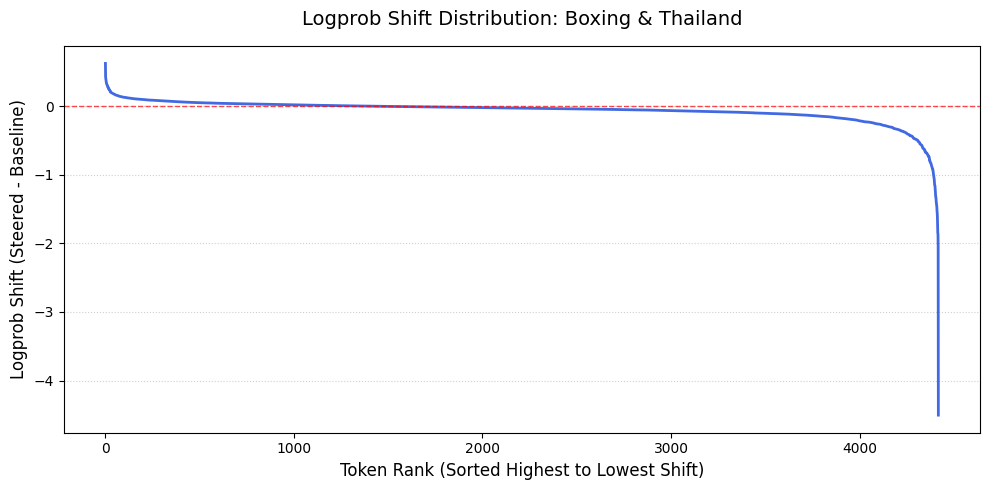

=== Extreme Logprob Shifts for: Boxing & Thailand ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' Royal'             | Shift:  0.6264 | Appearances: 15
' army'              | Shift:  0.4269 | Appearances: 12
' coup'              | Shift:  0.4010 | Appearances: 10
' Parad'             | Shift:  0.3826 | Appearances: 12
' Thailand'          | Shift:  0.3635 | Appearances: 137
' scientific'        | Shift:  0.3447 | Appearances: 17
' chances'           | Shift:  0.3378 | Appearances: 10
' par'               | Shift:  0.3211 | Appearances: 10
' Family'            | Shift:  0.3155 | Appearances: 12
' Please'            | Shift:  0.3125 | Appearances: 15
' Boxing'            | Shift:  0.3094 | Appearances: 30
'Th'                 | Shift:  0.2932 | Appearances: 20
' boxing'            | Shift:  0.2823 | Appearances: 88
' rival'             | Shift:  0.2816 | Appearances: 10
'akes'               | Shift:  0.2814 | Appearanc

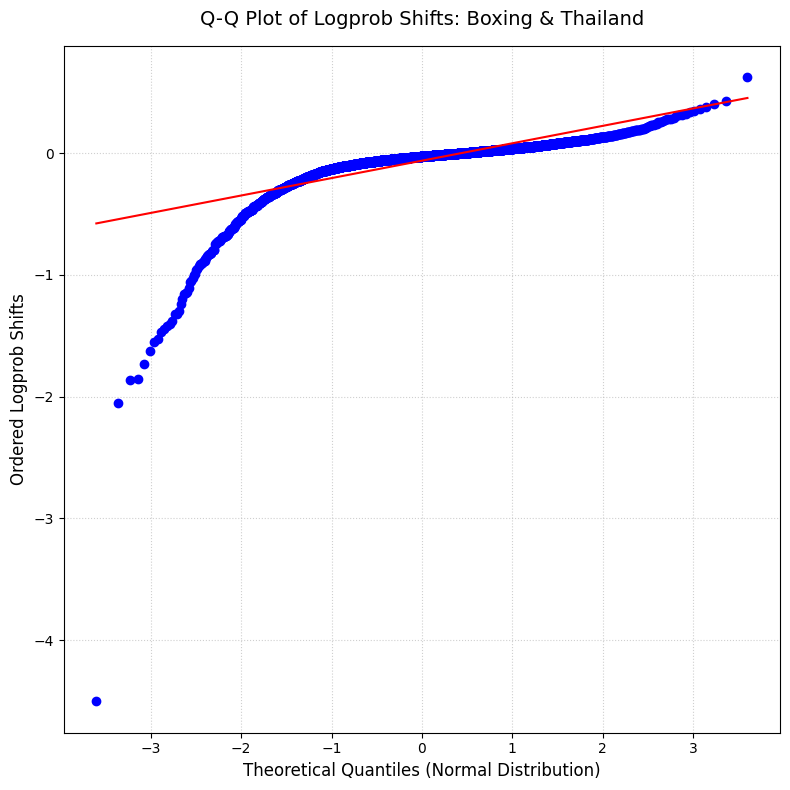

In [13]:
concepts = ["Boxing", "Thailand"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["Boxing", "Thailand"],
    neg_prompts= [" ", " "],
    hypotheses= ["Boxing", "Thailand","Muay Thai", "Combat"],
    layers= [1,2],
    coeffs= [3,3],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 2,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 2. Sports + Winter

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 140 for Sports
Found 55 for Winter
Found 55 for Winter Sports
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4327 unique tokens with >= 10 appearances.
Successfully saved 4327 rows to Sports+Winter-token_results.csv


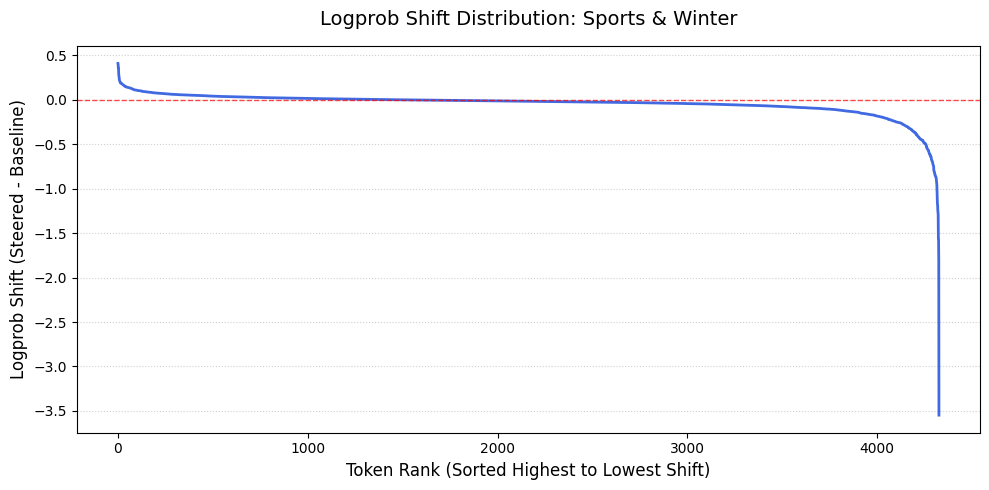

=== Extreme Logprob Shifts for: Sports & Winter ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' Wolves'            | Shift:  0.4103 | Appearances: 10
' suit'              | Shift:  0.3967 | Appearances: 10
' recording'         | Shift:  0.3592 | Appearances: 11
' IM'                | Shift:  0.3581 | Appearances: 10
' winter'            | Shift:  0.2903 | Appearances: 86
' stimulus'          | Shift:  0.2701 | Appearances: 10
' bowls'             | Shift:  0.2391 | Appearances: 16
' exclusive'         | Shift:  0.2366 | Appearances: 16
' pregnancy'         | Shift:  0.2202 | Appearances: 12
' champion'          | Shift:  0.2137 | Appearances: 26
' Birmingham'        | Shift:  0.2076 | Appearances: 16
' identity'          | Shift:  0.2026 | Appearances: 16
' Sta'               | Shift:  0.1965 | Appearances: 19
' sponsors'          | Shift:  0.1946 | Appearances: 11
' venue'             | Shift:  0.1935 | Appearances:

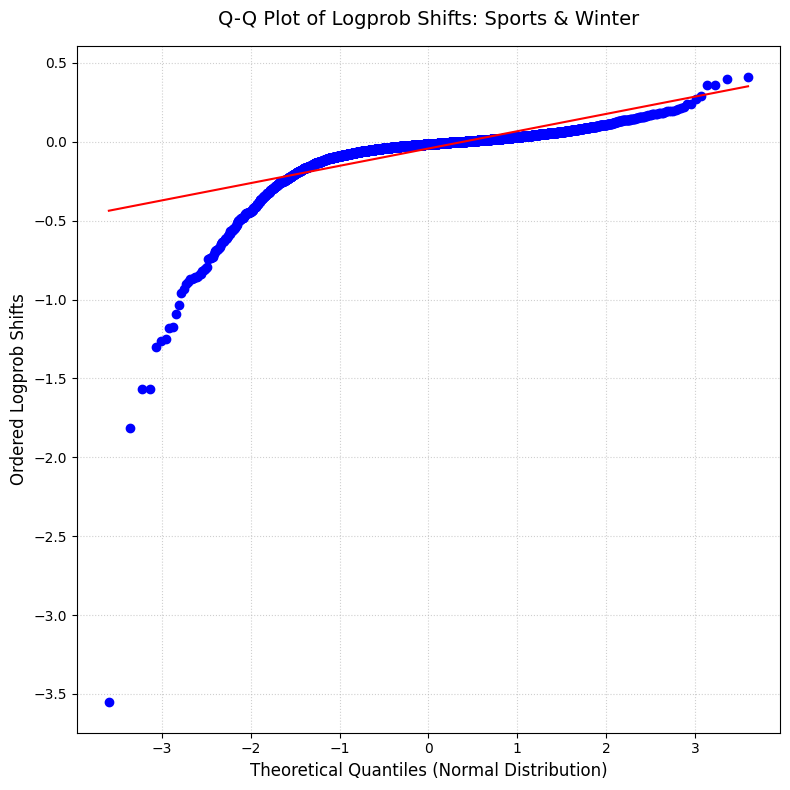

In [14]:
concepts = ["Sports","Winter"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["Sports", "I like winter"],
    neg_prompts= [" ", "I like summer"],
    hypotheses= ["Sports", "Winter", "Winter Sports"],
    layers= [1,2],
    coeffs= [3,3],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 3. The Sun + Eyeglasses

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 140 for The Sun
Found 55 for Eyeglasses
Found 55 for Sunglasses
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4444 unique tokens with >= 10 appearances.
Successfully saved 4444 rows to The Sun+Eyeglasses-token_results.csv


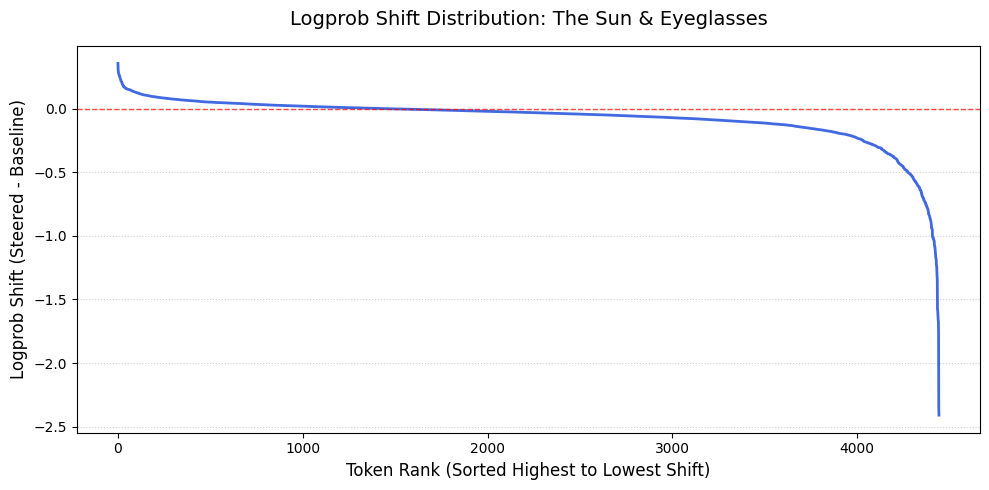

=== Extreme Logprob Shifts for: The Sun & Eyeglasses ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' sunglasses'        | Shift:  0.3542 | Appearances: 58
' guest'             | Shift:  0.3010 | Appearances: 10
' editorial'         | Shift:  0.2958 | Appearances: 10
' Australian'        | Shift:  0.2783 | Appearances: 10
' rival'             | Shift:  0.2735 | Appearances: 12
' college'           | Shift:  0.2712 | Appearances: 26
'�'                  | Shift:  0.2676 | Appearances: 179
' edge'              | Shift:  0.2582 | Appearances: 10
'�'                  | Shift:  0.2557 | Appearances: 11
' Te'                | Shift:  0.2553 | Appearances: 11
' department'        | Shift:  0.2471 | Appearances: 18
' wore'              | Shift:  0.2424 | Appearances: 16
' pregnancy'         | Shift:  0.2384 | Appearances: 13
' Glass'             | Shift:  0.2367 | Appearances: 33
' marked'            | Shift:  0.2305 | Appear

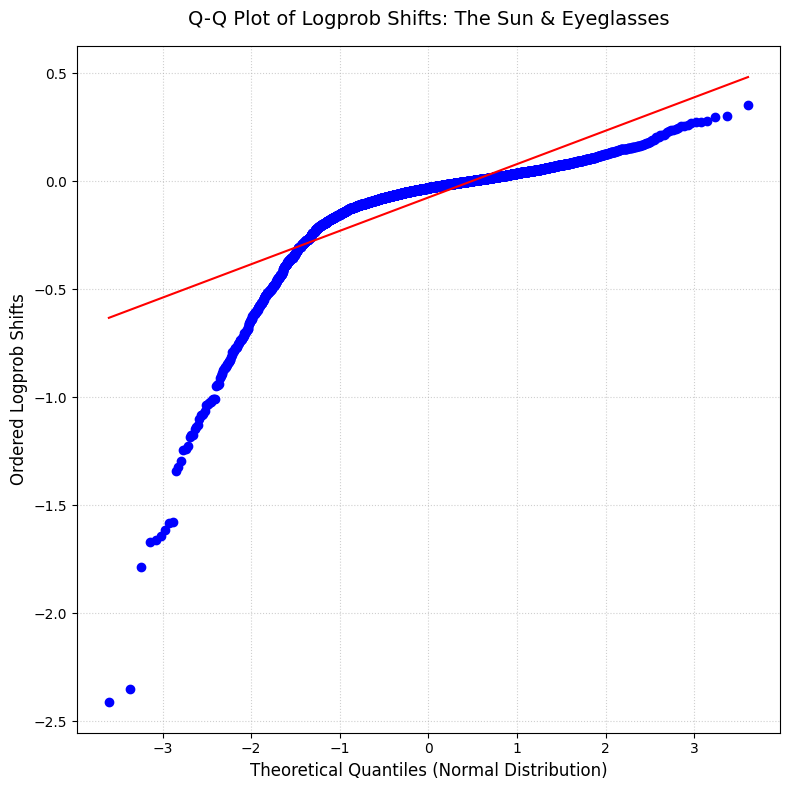

In [19]:
concepts = ["The Sun","Eyeglasses"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["the sun", "eyeglasses"],
    neg_prompts= [" ", " "],
    hypotheses= ["The Sun", "Eyeglasses", "Sunglasses"],
    layers= [1,2],
    coeffs= [4,3],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 1,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 4. Horse + Racing

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 103 for Horse
Found 92 for Racing
Found 55 for Horse Racing
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4445 unique tokens with >= 10 appearances.
Successfully saved 4445 rows to Horse+Racing-token_results.csv


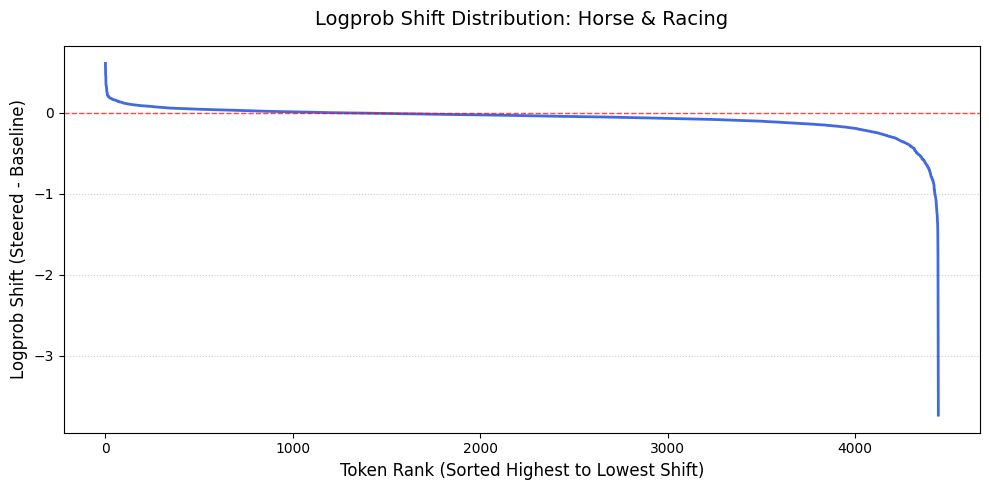

=== Extreme Logprob Shifts for: Horse & Racing ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
'�'                  | Shift:  0.6121 | Appearances: 17
' pregnancy'         | Shift:  0.4716 | Appearances: 12
'Ru'                 | Shift:  0.4533 | Appearances: 12
' Robinson'          | Shift:  0.3455 | Appearances: 13
' crash'             | Shift:  0.3429 | Appearances: 20
' lets'              | Shift:  0.3289 | Appearances: 10
' Pri'               | Shift:  0.3124 | Appearances: 17
' Tu'                | Shift:  0.2733 | Appearances: 16
'ford'               | Shift:  0.2670 | Appearances: 16
' Bruce'             | Shift:  0.2422 | Appearances: 10
'ockey'              | Shift:  0.2399 | Appearances: 47
' realize'           | Shift:  0.2186 | Appearances: 13
' entrance'          | Shift:  0.2141 | Appearances: 12
' Te'                | Shift:  0.2129 | Appearances: 12
' holiday'           | Shift:  0.2100 | Appearances: 

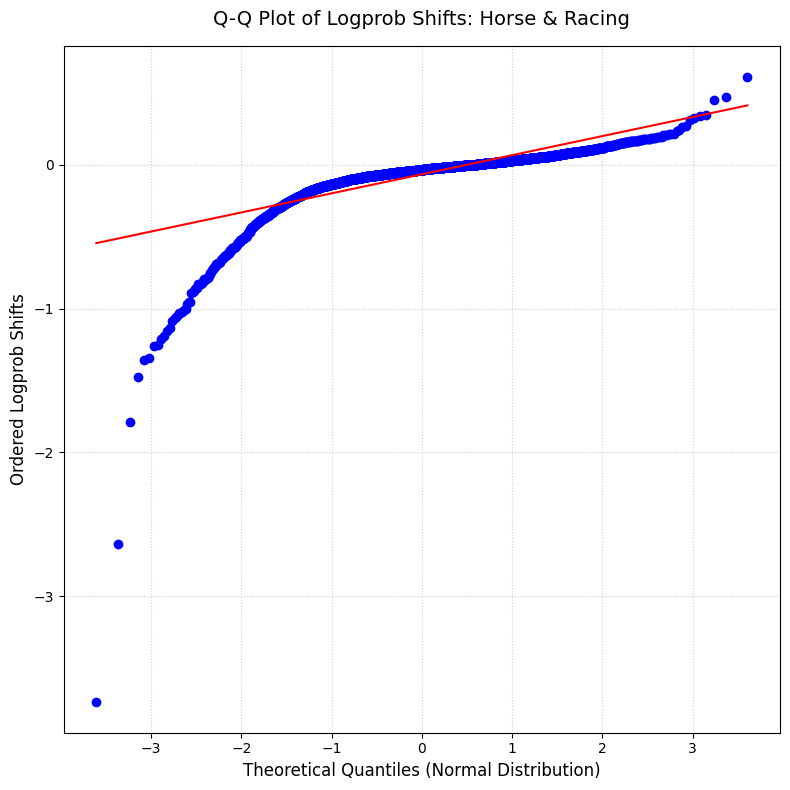

In [20]:
concepts = ["Horse","Racing"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["Horse", "Racing"],
    neg_prompts= [" ", " "],
    hypotheses= ["Horse", "Racing", "Horse Racing"],
    layers= [3,5],
    coeffs= [2.5,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 2,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 5. Polar + Bear

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 78 for Polar
Found 117 for Bear
Found 55 for Polar Bear
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4521 unique tokens with >= 10 appearances.
Successfully saved 4521 rows to Polar+Bear-token_results.csv


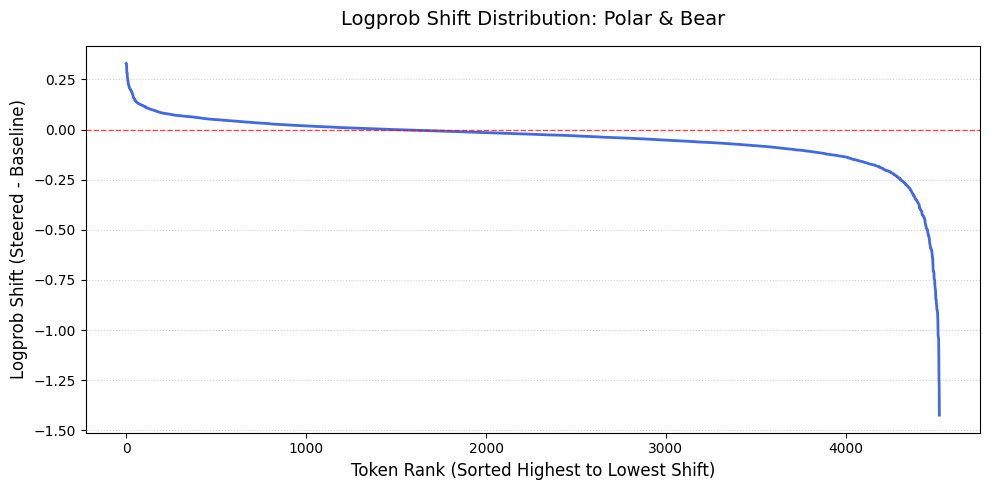

=== Extreme Logprob Shifts for: Polar & Bear ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' legend'            | Shift:  0.3296 | Appearances: 10
' Polar'             | Shift:  0.3287 | Appearances: 27
' pregnancy'         | Shift:  0.3049 | Appearances: 12
' Sher'              | Shift:  0.2826 | Appearances: 10
' Pig'               | Shift:  0.2824 | Appearances: 10
' par'               | Shift:  0.2822 | Appearances: 10
' lets'              | Shift:  0.2594 | Appearances: 10
' Crystal'           | Shift:  0.2571 | Appearances: 12
' Te'                | Shift:  0.2490 | Appearances: 13
' holiday'           | Shift:  0.2429 | Appearances: 11
' rival'             | Shift:  0.2415 | Appearances: 12
' helping'           | Shift:  0.2256 | Appearances: 10
' lean'              | Shift:  0.2244 | Appearances: 13
'ome'                | Shift:  0.2231 | Appearances: 14
'Car'                | Shift:  0.2214 | Appearances: 13

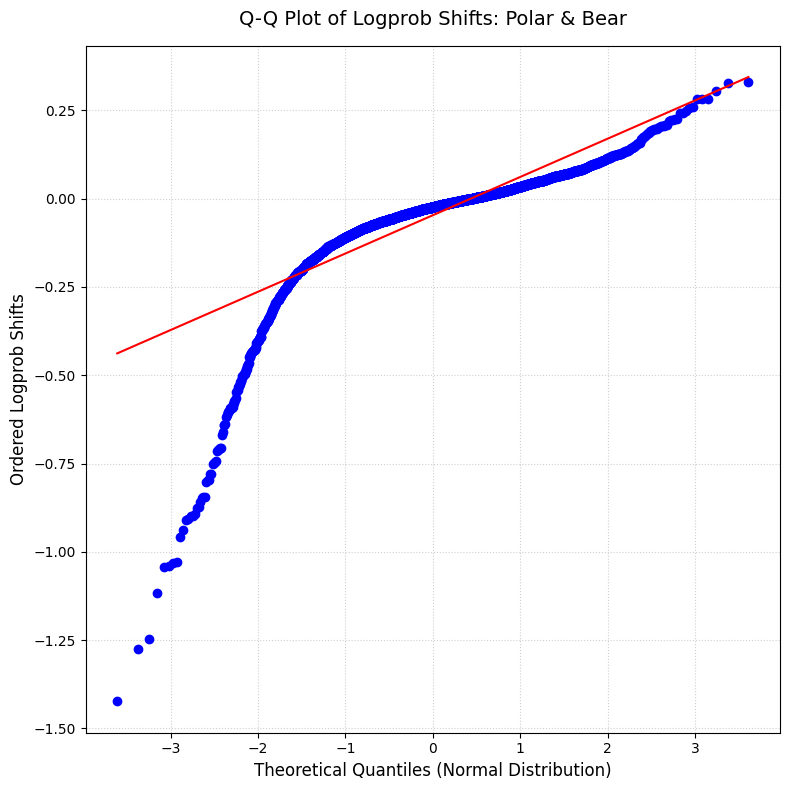

In [21]:
concepts = ["Polar","Bear"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["Polar", "Bear"],
    neg_prompts= [" ", " "],
    hypotheses= ["Polar", "Bear", "Polar Bear"],
    layers= [3,4],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 6. Value + Proposition

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 129 for Value
Found 66 for Proposition
Found 55 for Value Proposition
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4553 unique tokens with >= 10 appearances.
Successfully saved 4553 rows to Value+Proposition-token_results.csv


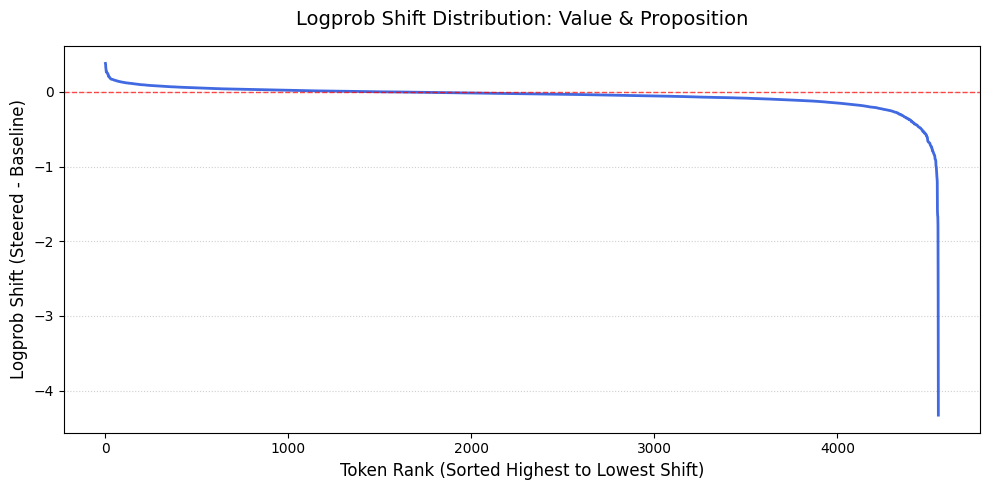

=== Extreme Logprob Shifts for: Value & Proposition ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' stake'             | Shift:  0.3807 | Appearances: 15
'Bitcoin'            | Shift:  0.3691 | Appearances: 13
' pitch'             | Shift:  0.3221 | Appearances: 15
' val'               | Shift:  0.3087 | Appearances: 16
' Project'           | Shift:  0.2794 | Appearances: 11
' crash'             | Shift:  0.2704 | Appearances: 16
' Polk'              | Shift:  0.2702 | Appearances: 11
' Pricing'           | Shift:  0.2589 | Appearances: 13
' proposition'       | Shift:  0.2564 | Appearances: 15
' partnership'       | Shift:  0.2561 | Appearances: 10
' Pitch'             | Shift:  0.2527 | Appearances: 10
' mainstream'        | Shift:  0.2527 | Appearances: 19
' valuation'         | Shift:  0.2427 | Appearances: 35
'Obviously'          | Shift:  0.2410 | Appearances: 10
' NSA'               | Shift:  0.2370 | Appearan

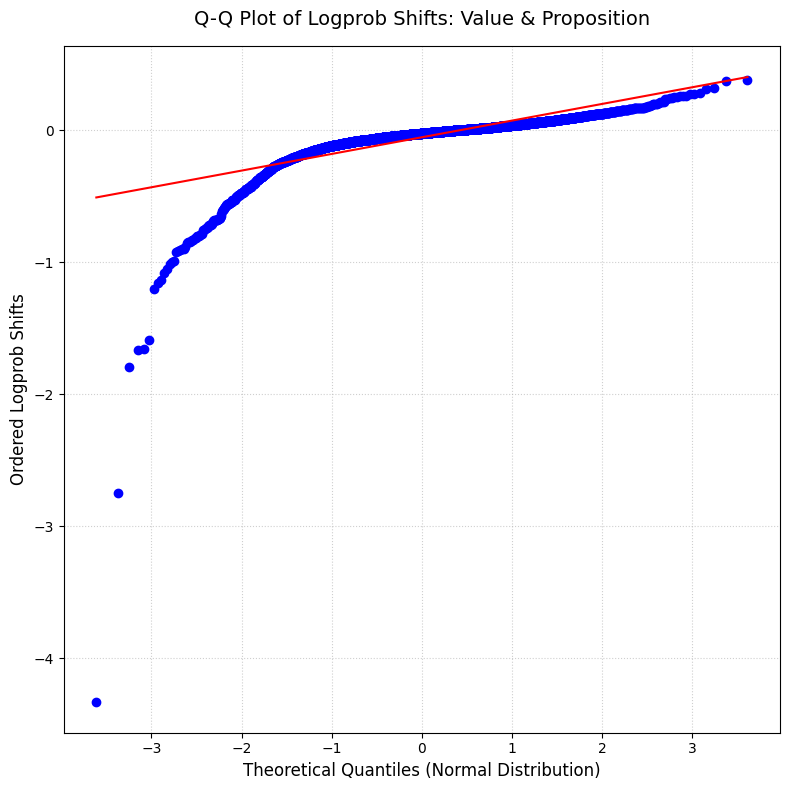

In [22]:
concepts = ["Value","Proposition"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["Value", "Proposition"],
    neg_prompts= [" ", " "],
    hypotheses= ["Value", "Proposition", "Value Proposition"],
    layers= [3,4],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 2,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 7. Toilet + Paper

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 55 for Toilet
Found 140 for Paper
Found 55 for Toilet Paper
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4356 unique tokens with >= 10 appearances.
Successfully saved 4356 rows to Toilet+Paper-token_results.csv


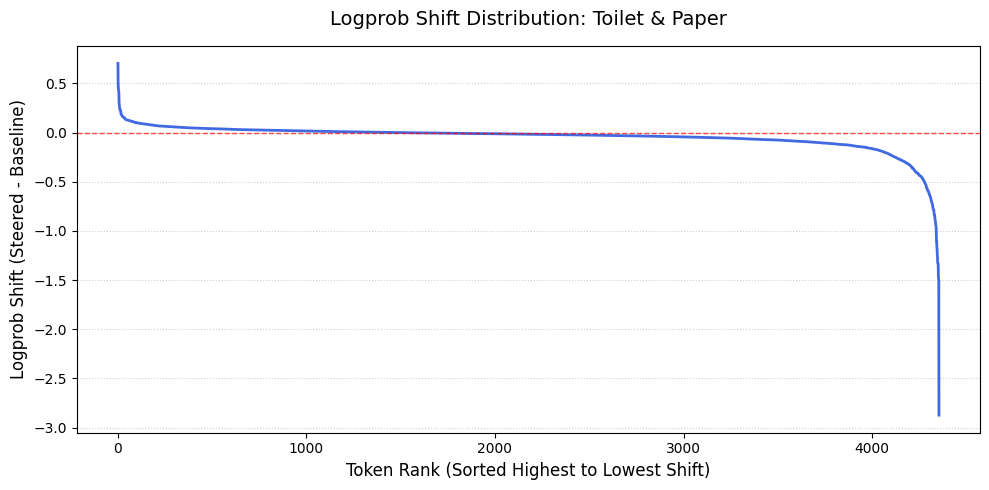

=== Extreme Logprob Shifts for: Toilet & Paper ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' Trans'             | Shift:  0.7027 | Appearances: 10
' lets'              | Shift:  0.4998 | Appearances: 11
' join'              | Shift:  0.4500 | Appearances: 13
' pee'               | Shift:  0.4264 | Appearances: 11
' toilet'            | Shift:  0.4234 | Appearances: 281
' soap'              | Shift:  0.3964 | Appearances: 11
' flush'             | Shift:  0.3020 | Appearances: 12
'ump'                | Shift:  0.2846 | Appearances: 13
' Family'            | Shift:  0.2654 | Appearances: 11
' parchment'         | Shift:  0.2411 | Appearances: 11
' ACC'               | Shift:  0.2327 | Appearances: 12
' Birmingham'        | Shift:  0.2324 | Appearances: 14
' suffer'            | Shift:  0.2297 | Appearances: 12
' rival'             | Shift:  0.2249 | Appearances: 10
' Parliament'        | Shift:  0.2239 | Appearances:

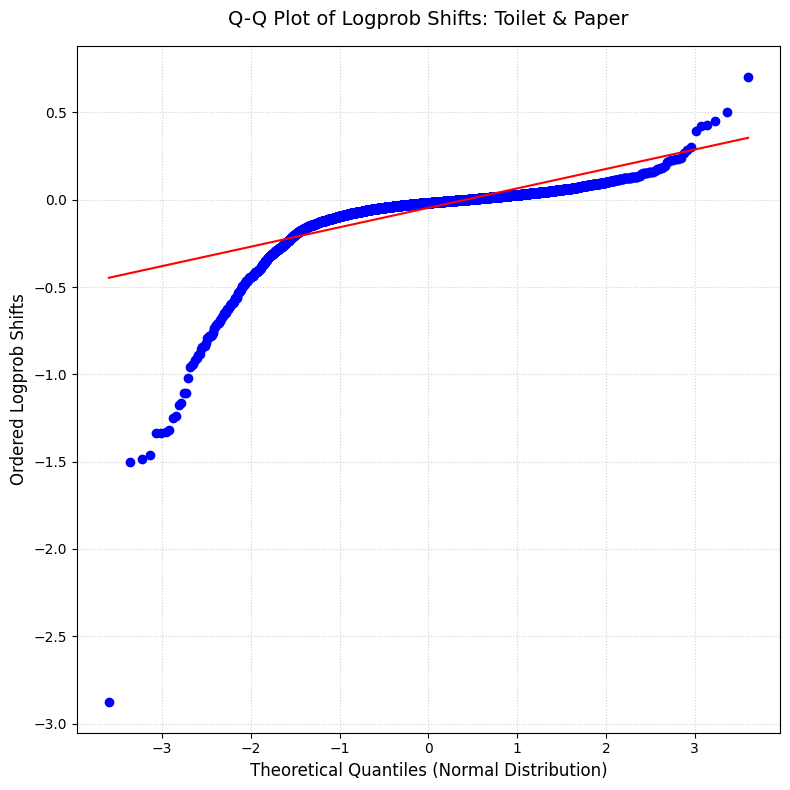

In [23]:
concepts = ["Toilet","Paper"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["Toilet", "Paper"],
    neg_prompts= [" ", " "],
    hypotheses= ["Toilet","Paper","Toilet Paper"],
    layers= [3,1],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 8. Japanese + Cartoon

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 55 for Cartoon
Found 140 for Japanese
Found 55 for Anime
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4302 unique tokens with >= 10 appearances.
Successfully saved 4302 rows to Japanese+Cartoon-token_results.csv


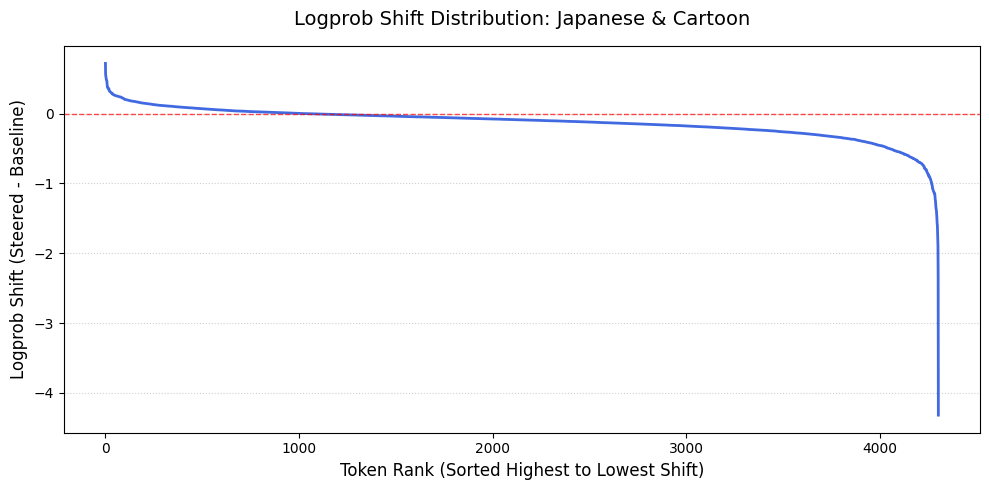

=== Extreme Logprob Shifts for: Japanese & Cartoon ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
'Cl'                 | Shift:  0.7168 | Appearances: 11
' monster'           | Shift:  0.5562 | Appearances: 11
'ase'                | Shift:  0.5321 | Appearances: 10
' Kyoto'             | Shift:  0.5043 | Appearances: 23
' ordered'           | Shift:  0.4954 | Appearances: 16
'aka'                | Shift:  0.4815 | Appearances: 18
'ren'                | Shift:  0.4763 | Appearances: 13
'una'                | Shift:  0.4732 | Appearances: 10
' 90'                | Shift:  0.4406 | Appearances: 11
' patrol'            | Shift:  0.4054 | Appearances: 11
' match'             | Shift:  0.3790 | Appearances: 17
'j'                  | Shift:  0.3715 | Appearances: 55
' orders'            | Shift:  0.3709 | Appearances: 11
'�'                  | Shift:  0.3703 | Appearances: 16
' par'               | Shift:  0.3649 | Appearanc

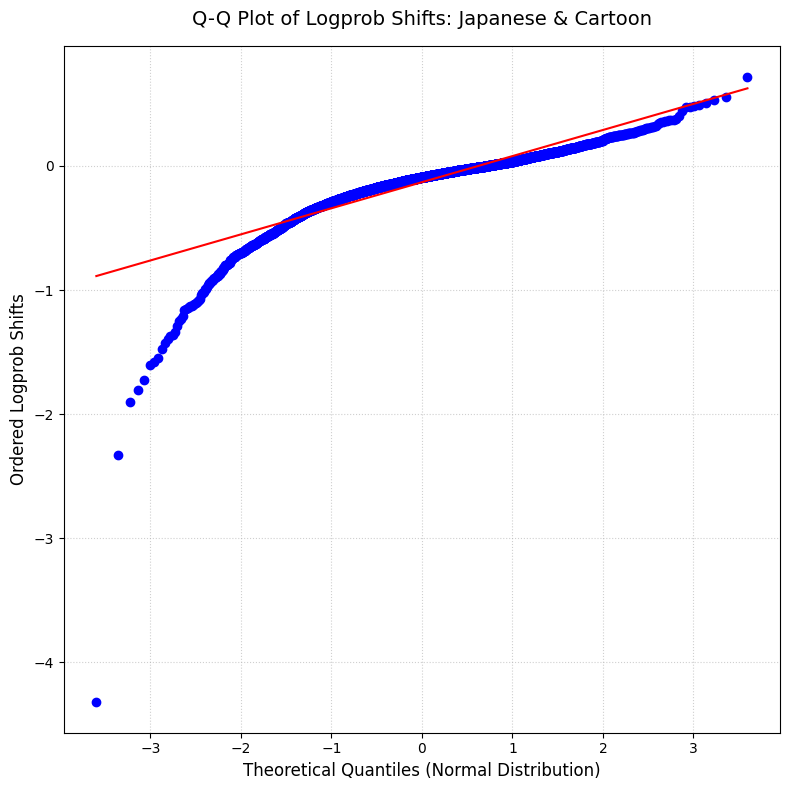

In [24]:
concepts = ["Japanese","Cartoon"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["Japanese","Cartoon"],
    neg_prompts= [" ", " "],
    hypotheses= ["Cartoon","Japanese","Anime"],
    layers= [1,2],
    coeffs= [10,3],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 9. Pacifist vs Murderous

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 55 for Pacifism
Found 97 for Violent Crimes
Found 98 for Murder
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4400 unique tokens with >= 10 appearances.
Successfully saved 4400 rows to Pacifist+Murderous-token_results.csv


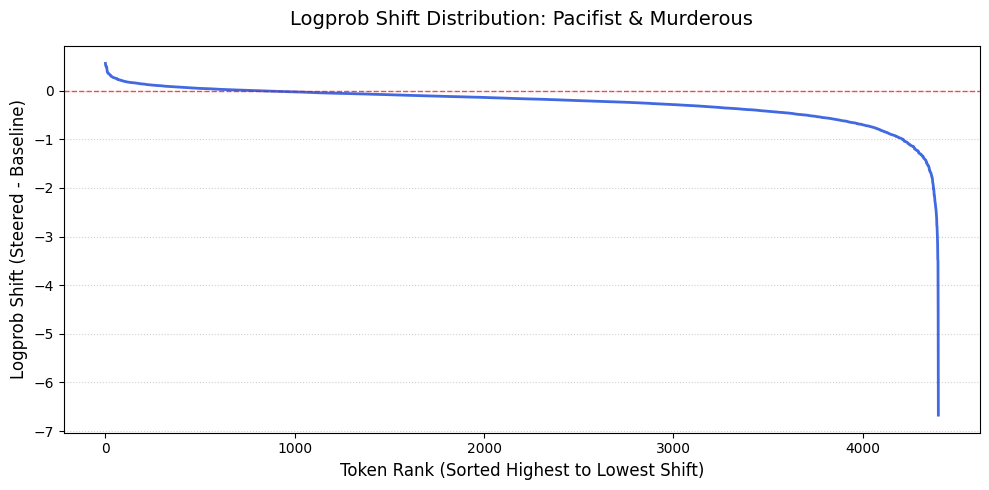

=== Extreme Logprob Shifts for: Pacifist & Murderous ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' newsletter'        | Shift:  0.5608 | Appearances: 11
'My'                 | Shift:  0.5217 | Appearances: 34
' Mar'               | Shift:  0.5185 | Appearances: 16
' murderer'          | Shift:  0.5144 | Appearances: 15
' massacre'          | Shift:  0.4905 | Appearances: 10
' controversial'     | Shift:  0.4900 | Appearances: 10
' am'                | Shift:  0.4879 | Appearances: 80
' Ar'                | Shift:  0.4722 | Appearances: 12
'ric'                | Shift:  0.4322 | Appearances: 12
' Sun'               | Shift:  0.4137 | Appearances: 16
' cannot'            | Shift:  0.3839 | Appearances: 31
'ign'                | Shift:  0.3814 | Appearances: 11
' loved'             | Shift:  0.3766 | Appearances: 13
' horror'            | Shift:  0.3661 | Appearances: 17
' aggressive'        | Shift:  0.3558 | Appeara

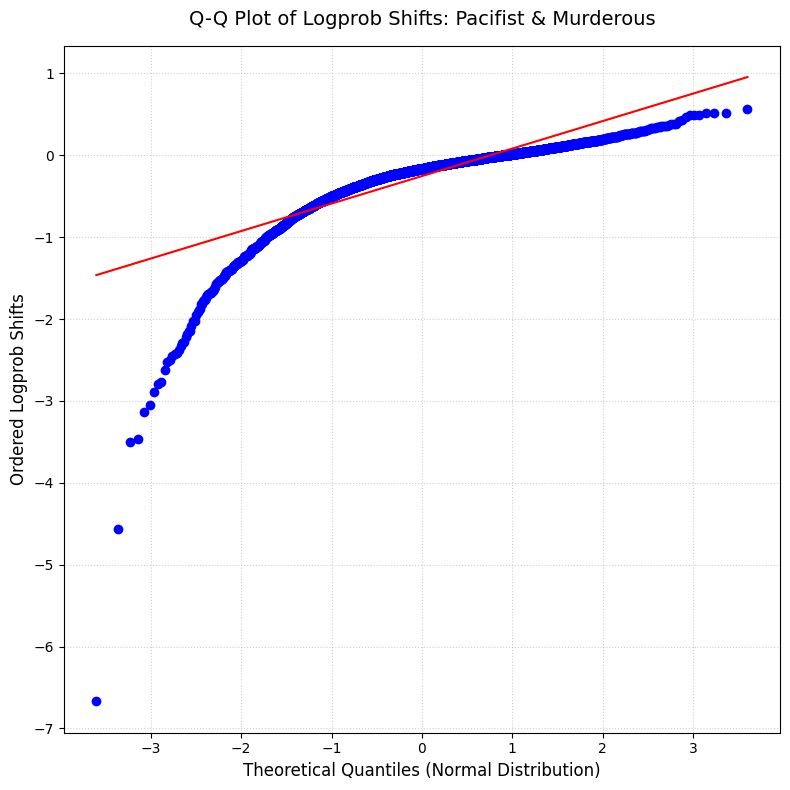

In [26]:
concepts = ["Pacifist","Murderous"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["I am a comitted pacifist", "I am murderous"],
    neg_prompts= [" ", " "],
    hypotheses= ["Pacifism","Violent Crimes","Murder"],
    layers= [10,30],
    coeffs= [7,7],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 10. Rich vs Poor

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 77 for Being Rich
Found 173 for Being Poor
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4404 unique tokens with >= 10 appearances.
Successfully saved 4404 rows to Rich+Poor-token_results.csv


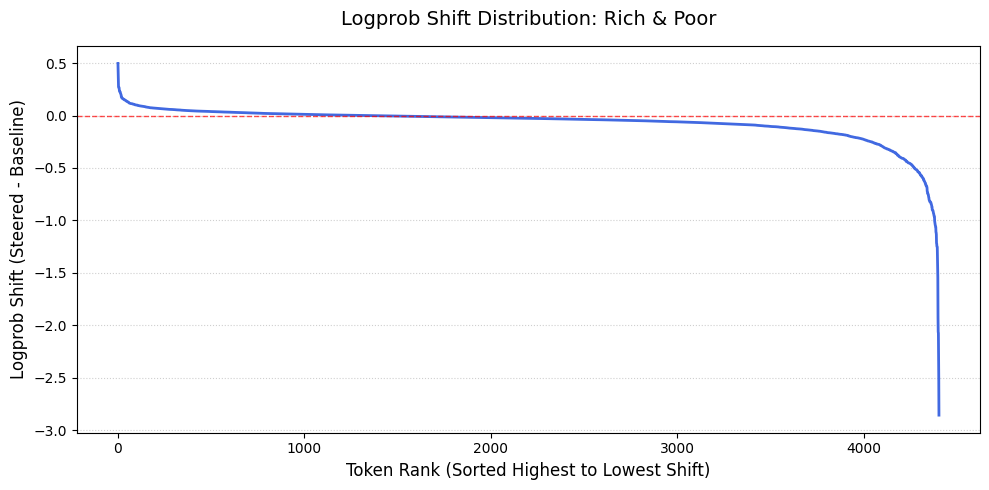

=== Extreme Logprob Shifts for: Rich & Poor ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' signing'           | Shift:  0.4973 | Appearances: 14
'�'                  | Shift:  0.4140 | Appearances: 18
' pregnancy'         | Shift:  0.3144 | Appearances: 17
' constant'          | Shift:  0.2746 | Appearances: 10
' musical'           | Shift:  0.2688 | Appearances: 10
' thousand'          | Shift:  0.2687 | Appearances: 10
' Robinson'          | Shift:  0.2676 | Appearances: 10
'j'                  | Shift:  0.2512 | Appearances: 29
'My'                 | Shift:  0.2334 | Appearances: 27
' cash'              | Shift:  0.2297 | Appearances: 26
' lawyer'            | Shift:  0.2292 | Appearances: 10
' parked'            | Shift:  0.2269 | Appearances: 10
' am'                | Shift:  0.2269 | Appearances: 79
'BI'                 | Shift:  0.2156 | Appearances: 10
' Pick'              | Shift:  0.2126 | Appearances: 10


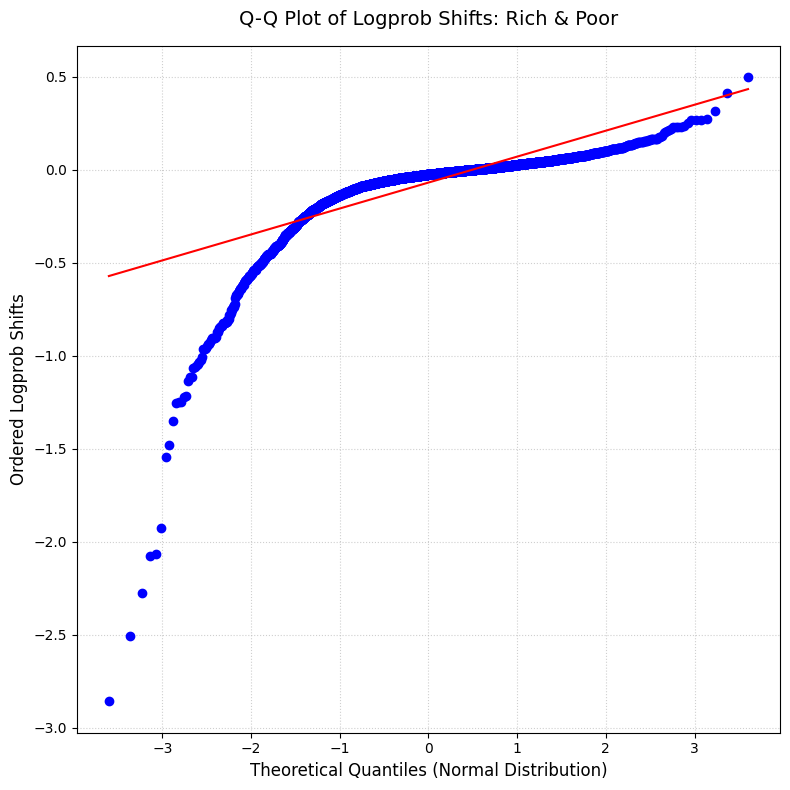

In [27]:
concepts = ["Rich","Poor"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["I am rich", "I am poor"],
    neg_prompts= [" ", " "],
    hypotheses= ["Being Rich","Being Poor"],
    layers= [3,4],
    coeffs= [1.5,1.5],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 11. Desert + Rainforest

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 55 for Desert
Found 55 for Rainforest
Found 140 for Forest
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4573 unique tokens with >= 10 appearances.
Successfully saved 4573 rows to Desert+Rainforest-token_results.csv


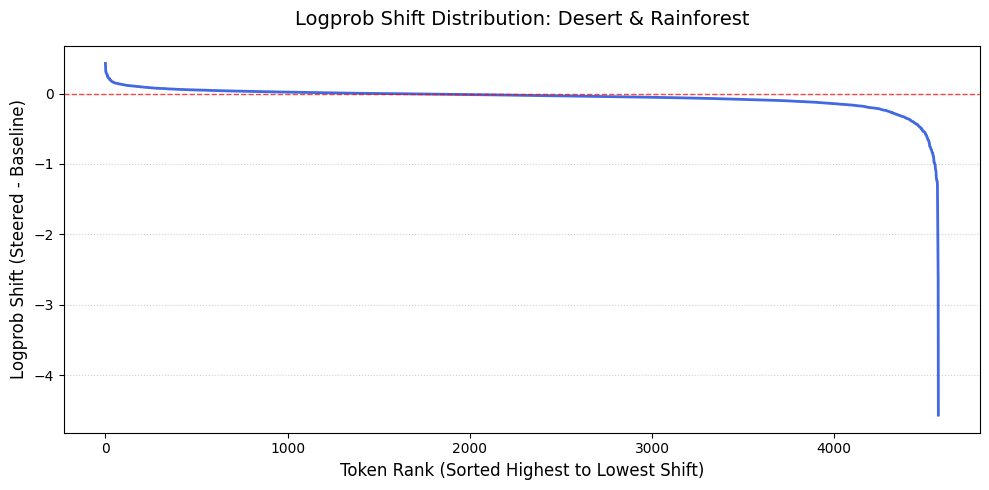

=== Extreme Logprob Shifts for: Desert & Rainforest ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' resume'            | Shift:  0.4289 | Appearances: 10
' pine'              | Shift:  0.3566 | Appearances: 14
' rain'              | Shift:  0.3082 | Appearances: 81
'ologists'           | Shift:  0.3044 | Appearances: 12
' rival'             | Shift:  0.3025 | Appearances: 10
' Euro'              | Shift:  0.2918 | Appearances: 13
' Jungle'            | Shift:  0.2822 | Appearances: 52
' choice'            | Shift:  0.2798 | Appearances: 24
' ski'               | Shift:  0.2748 | Appearances: 12
' Lemon'             | Shift:  0.2726 | Appearances: 10
' southwest'         | Shift:  0.2571 | Appearances: 14
' Bl'                | Shift:  0.2561 | Appearances: 15
' lawsuit'           | Shift:  0.2549 | Appearances: 10
' Car'               | Shift:  0.2337 | Appearances: 11
' musical'           | Shift:  0.2309 | Appearan

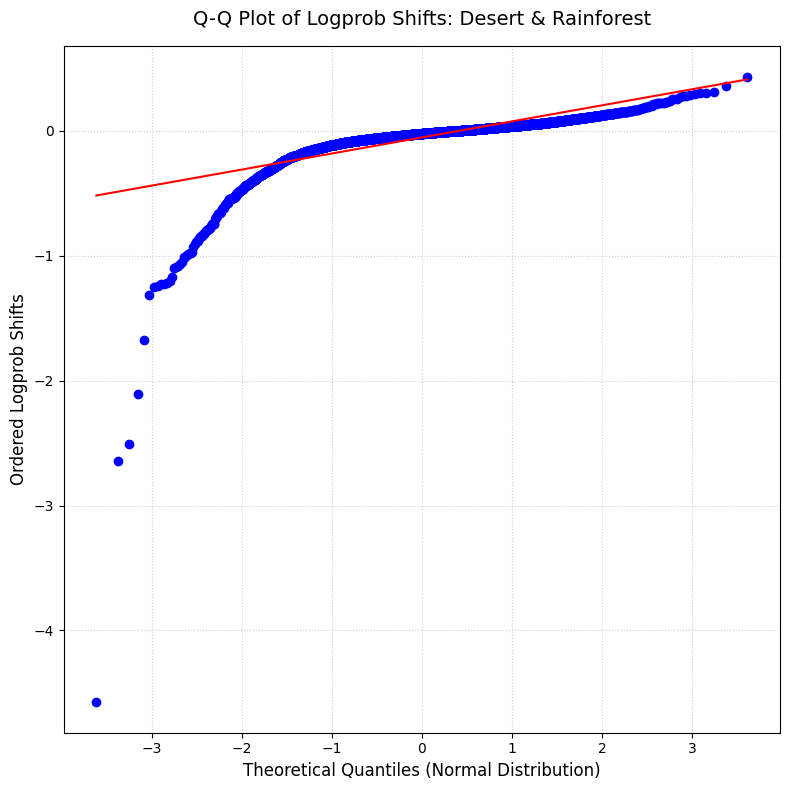

In [28]:
concepts = ["Desert","Rainforest"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["Desert", "Rainforest"],
    neg_prompts= [" ", " "],
    hypotheses= ["Desert","Rainforest","Forest"],
    layers= [2,4],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 12. Man vs Woman

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 250 for Gender
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4191 unique tokens with >= 10 appearances.
Successfully saved 4191 rows to I talk like a man+I talk like a woman-token_results.csv


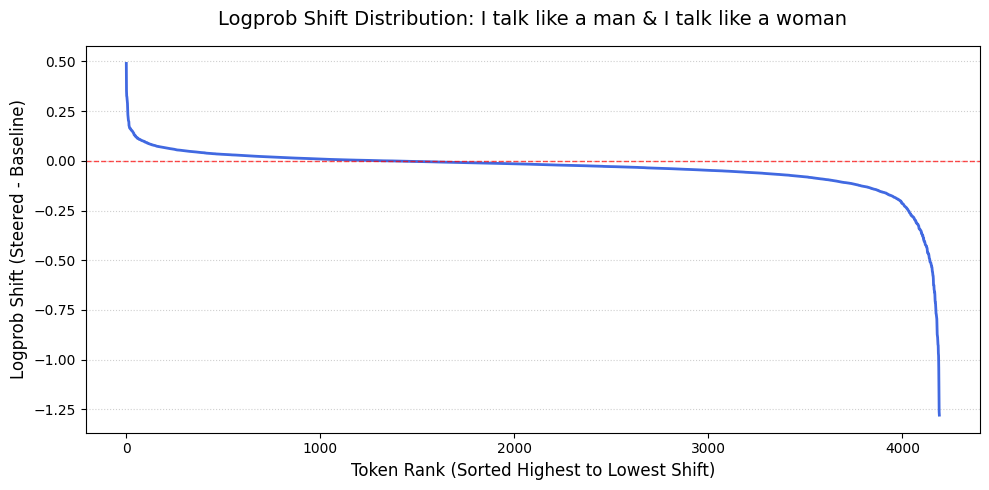

=== Extreme Logprob Shifts for: I talk like a man & I talk like a woman ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' First'             | Shift:  0.4902 | Appearances: 17
' legend'            | Shift:  0.3524 | Appearances: 13
' Mir'               | Shift:  0.3258 | Appearances: 12
' titles'            | Shift:  0.3221 | Appearances: 12
'ank'                | Shift:  0.3088 | Appearances: 10
' NSA'               | Shift:  0.2971 | Appearances: 22
' Bl'                | Shift:  0.2887 | Appearances: 17
' Vin'               | Shift:  0.2572 | Appearances: 13
' grown'             | Shift:  0.2326 | Appearances: 10
' adds'              | Shift:  0.2217 | Appearances: 12
' charge'            | Shift:  0.2143 | Appearances: 29
' committee'         | Shift:  0.2023 | Appearances: 27
' surrog'            | Shift:  0.2001 | Appearances: 19
' Jason'             | Shift:  0.1975 | Appearances: 10
' officially'        | Shift

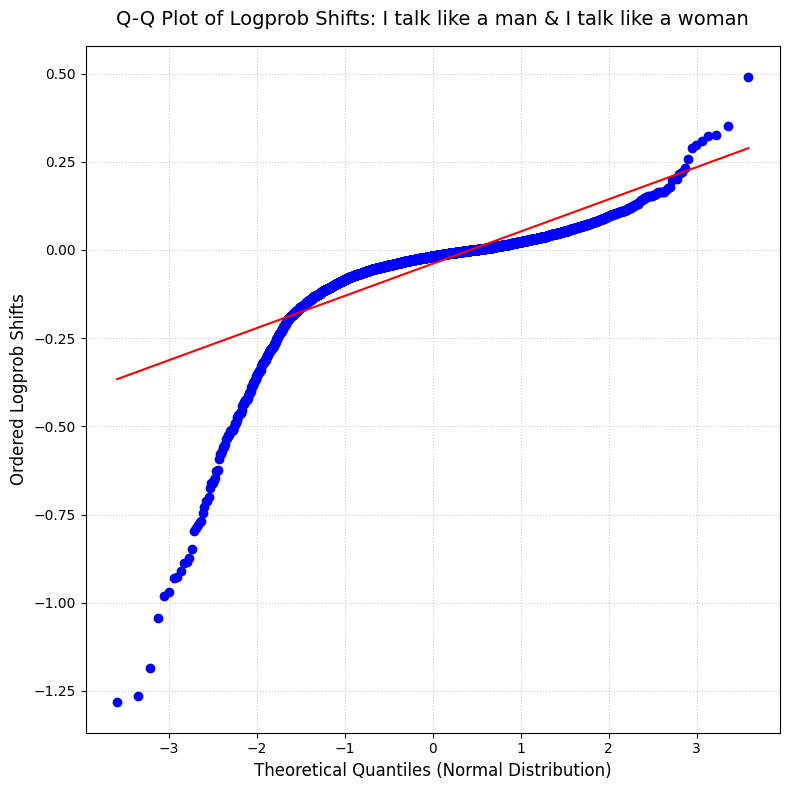

In [29]:
concepts = ["I talk like a man","I talk like a woman"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["I talk like a man", "I talk like a woman"],
    neg_prompts= ["I talk like a woman", "I talk like a man"],
    hypotheses= ["Gender"],
    layers= [9,3],
    coeffs= [9,9],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 13. Winner vs Loser

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 165 for I talk like a winner
Found 85 for I talk like a loser
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4425 unique tokens with >= 10 appearances.
Successfully saved 4425 rows to I talk like a winner+I talk like a loser-token_results.csv


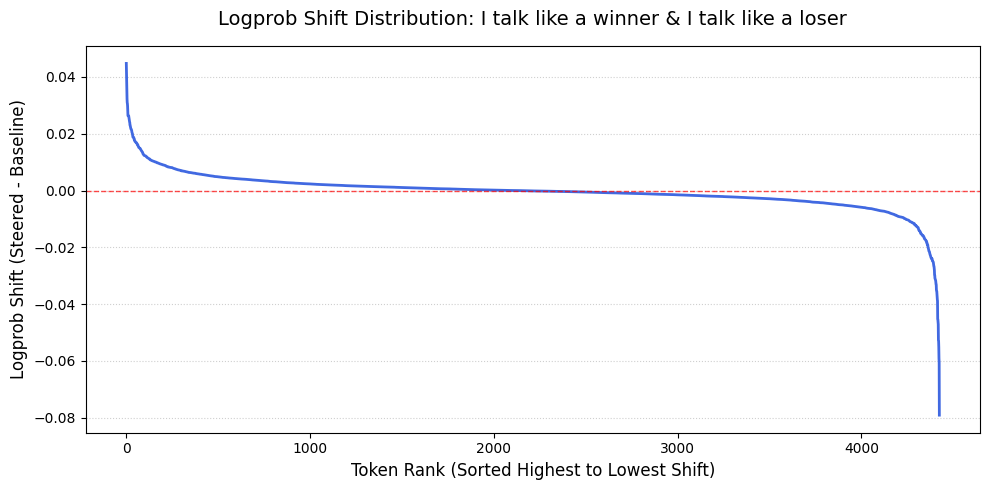

=== Extreme Logprob Shifts for: I talk like a winner & I talk like a loser ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' LA'                | Shift:  0.0448 | Appearances: 14
' Gay'               | Shift:  0.0414 | Appearances: 11
'Come'               | Shift:  0.0401 | Appearances: 12
' chapter'           | Shift:  0.0332 | Appearances: 14
' coffee'            | Shift:  0.0323 | Appearances: 11
' criticism'         | Shift:  0.0310 | Appearances: 15
' books'             | Shift:  0.0306 | Appearances: 10
'vern'               | Shift:  0.0298 | Appearances: 16
' lets'              | Shift:  0.0273 | Appearances: 14
' cur'               | Shift:  0.0264 | Appearances: 10
' September'         | Shift:  0.0264 | Appearances: 44
' Bloomberg'         | Shift:  0.0263 | Appearances: 12
' Syrian'            | Shift:  0.0263 | Appearances: 13
'OD'                 | Shift:  0.0263 | Appearances: 11
' neural'            | Sh

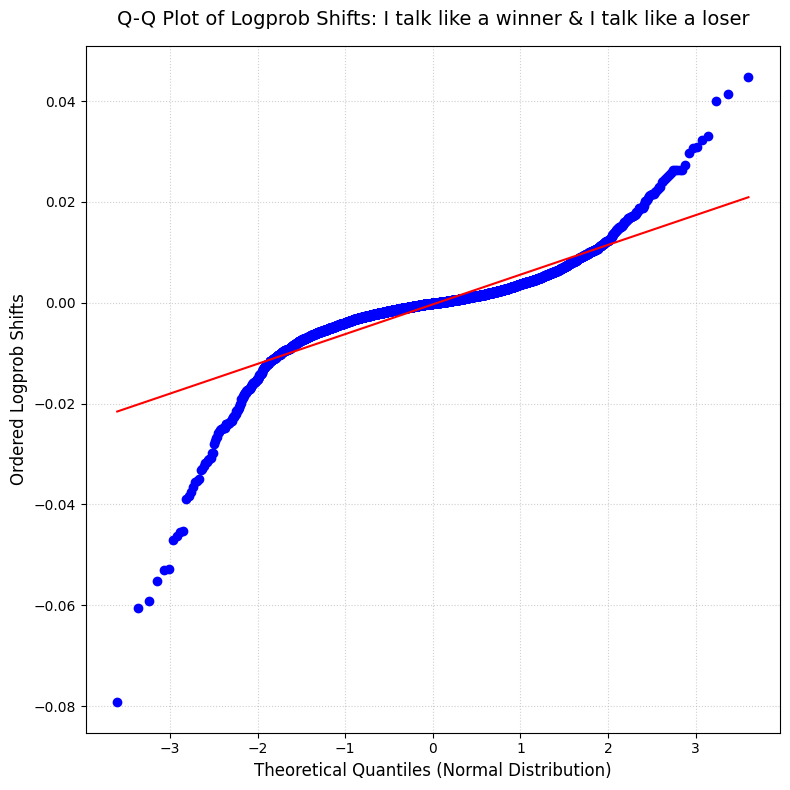

In [ ]:
concepts = ["I talk like a winner","I talk like a loser"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["I talk like a winner", "I talk like a loser"],
    neg_prompts= ["I talk like a loser", "I talk like a winner"],
    hypotheses= ["I talk like a winner","I talk like a loser"],
    layers= [5,4],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts) + '1')

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 14. Winner vs loser

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 165 for I talk like a winner
Found 85 for I talk like a loser
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4425 unique tokens with >= 10 appearances.
Successfully saved 4425 rows to I talk like a winner+I talk like a loser-token_results.csv


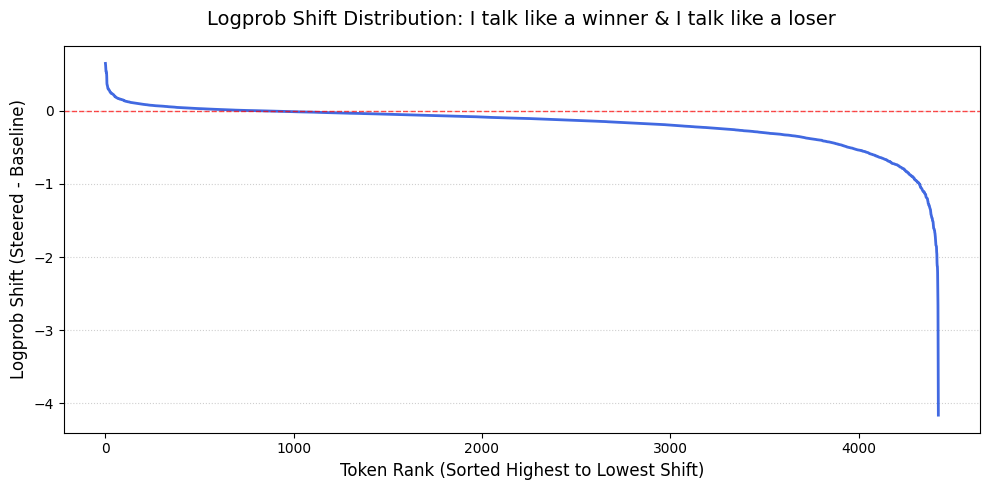

=== Extreme Logprob Shifts for: I talk like a winner & I talk like a loser ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' Gay'               | Shift:  0.6443 | Appearances: 11
'�'                  | Shift:  0.6195 | Appearances: 1434
' fat'               | Shift:  0.5746 | Appearances: 10
'�'                  | Shift:  0.5364 | Appearances: 177
'�'                  | Shift:  0.5356 | Appearances: 1358
' qu'                | Shift:  0.5183 | Appearances: 11
'..'                 | Shift:  0.5172 | Appearances: 11
' handed'            | Shift:  0.4670 | Appearances: 11
' er'                | Shift:  0.3711 | Appearances: 10
' flow'              | Shift:  0.3514 | Appearances: 11
' hip'               | Shift:  0.3476 | Appearances: 11
' ,'                 | Shift:  0.3336 | Appearances: 53
' First'             | Shift:  0.3135 | Appearances: 32
' .'                 | Shift:  0.3067 | Appearances: 80
' Bl'               

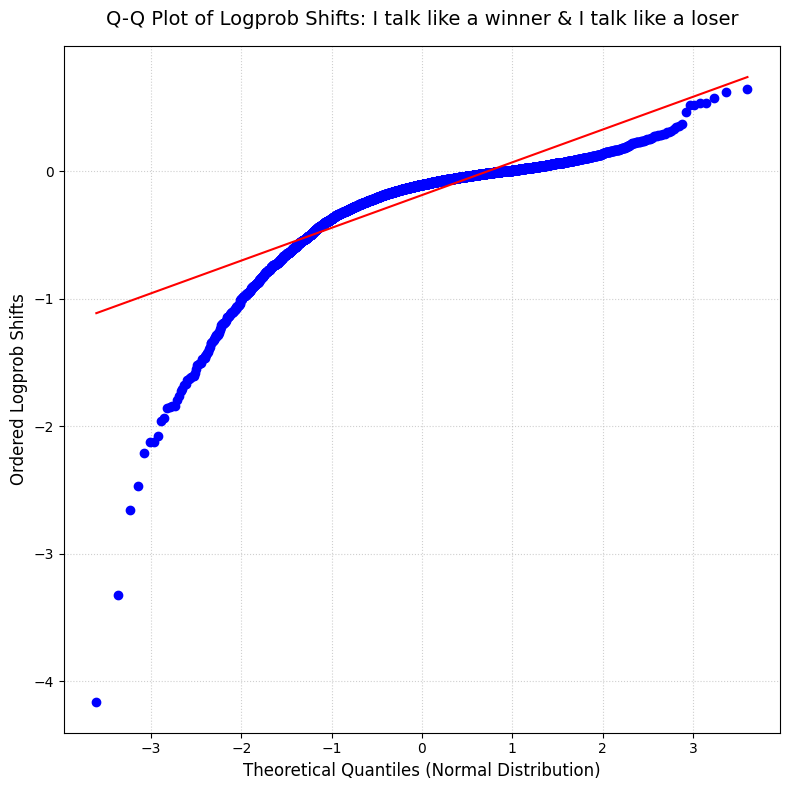

In [ ]:
concepts = ["I talk like a winner","I talk like a loser"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["I talk like a winner", "I talk like a loser"],
    neg_prompts= ["I do not talk like a winner", "I do not talk like a loser"],
    hypotheses= ["I talk like a winner","I talk like a loser"],
    layers= [5,4],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts) + '2')

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 15. Cold vs Warm

1. Generating Activation Addition hooks...

2. Getting 500 documents...
Found 77 for Clothes
Found 68 for Temperature
Found 105 for Love
500


Evaluating Batches:   0%|          | 0/125 [00:00<?, ?it/s]


3. Calculating averages and filtering...
Finished. Kept 4345 unique tokens with >= 10 appearances.
Successfully saved 4345 rows to Cold+Warm-token_results.csv


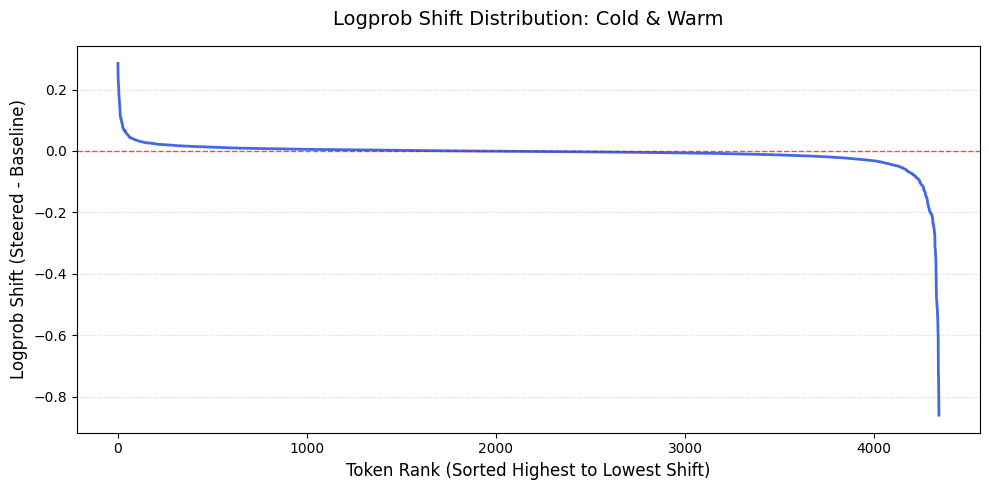

=== Extreme Logprob Shifts for: Cold & Warm ===

Top 50 Increased Tokens (Highest Positive Shift):
------------------------------------------------------------
' Chandra'           | Shift:  0.2852 | Appearances: 10
' horn'              | Shift:  0.2373 | Appearances: 10
' concern'           | Shift:  0.2220 | Appearances: 20
' Weaver'            | Shift:  0.2116 | Appearances: 11
'ude'                | Shift:  0.2057 | Appearances: 17
' library'           | Shift:  0.1832 | Appearances: 12
' Birmingham'        | Shift:  0.1786 | Appearances: 14
' General'           | Shift:  0.1682 | Appearances: 12
' Banner'            | Shift:  0.1563 | Appearances: 21
' Thank'             | Shift:  0.1492 | Appearances: 10
' algorithm'         | Shift:  0.1465 | Appearances: 10
' Gov'               | Shift:  0.1270 | Appearances: 12
' Sl'                | Shift:  0.1170 | Appearances: 13
' contracts'         | Shift:  0.1136 | Appearances: 12
' chart'             | Shift:  0.1119 | Appearances: 13


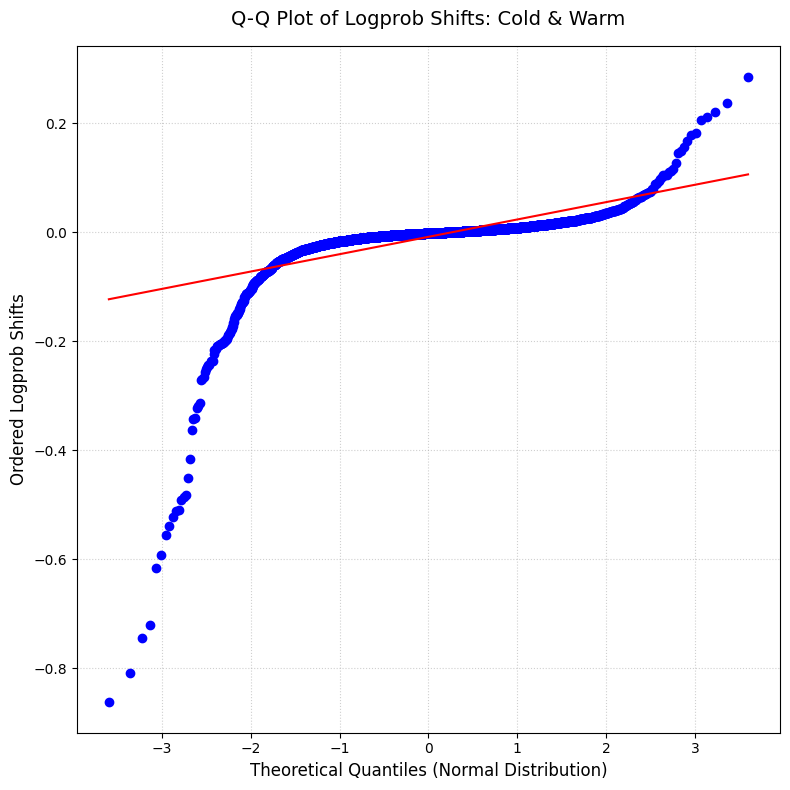

In [32]:
concepts = ["Cold","Warm"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["It is cold in here", "It is warm in here"],
    neg_prompts= ["It is warm in here", "It is cold in here"],
    hypotheses= ["Clothes","Temperature","Love"],
    layers= [1,3],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 16. Cold vs Warm

In [ ]:
concepts = ["Cold","Warm"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["It is cold in here", "It is warm in here"],
    neg_prompts= ["It is not cold in here", "It is not warm in here"],
    hypotheses= ["Clothes","Temperature","Love"],
    layers= [1,3],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 17. Vegeterian vs Meat

In [ ]:
concepts = ["Vegetarian","Meat-eater"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["I am a vegetarian", "I love eating meat"],
    neg_prompts= ["I am not a vegetarian", "I hate eating meat"],
    hypotheses= ["Vegan","Meat","Food"],
    layers= [1,3],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 18. Vegeterian vs Meat

In [ ]:
concepts = ["Vegetarian","Meat-eater"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["I am a vegetarian", "I love eating meat"],
    neg_prompts= ["I love eating meat", "I am a vegetarian"],
    hypotheses= ["Vegan","Meat","Food"],
    layers= [1,3],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 19. Winter vs Summer

In [ ]:
concepts = ["Winter","Summer"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["It is winter", "It is summer"],
    neg_prompts= ["It is not winter", "It is not summer"],
    hypotheses= ["Summertime","Wintertime","Summer Activities"],
    layers= [5,3],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)


#### 20. Winter vs Summer

In [ ]:
concepts = ["Winter","Summer"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["It is winter", "It is summer"],
    neg_prompts= ["It is summer", "It is winter"],
    hypotheses= ["Summertime","Wintertime","Summer Activities"],
    layers= [5,3],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)


#### 21. Day vs Night

In [ ]:
concepts = ["Day", "Night"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["It is daytime","It is nighttime"],
    neg_prompts= ["It is not daytime", "It is not nighttime"],
    hypotheses=["Night","Morning"],
    layers= [6,8],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)

#### 22. Day vs Night

In [ ]:
concepts = ["Day", "Night"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["It is daytime","It is nighttime"],
    neg_prompts= ["It is nighttime", "It is daytime"],
    hypotheses=["Night","Morning"],
    layers= [6,8],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)


#### 23. Basketball vs Not Basketball

In [ ]:
concepts = ["Basketball","Not Basketball"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["Basketball"," "],
    neg_prompts= [" ","Basketball"],
    hypotheses=["Basketball"],
    layers= [1,3],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)



#### 24. Restaurant vs Not Restaurant

In [ ]:
concepts = ["Restaurant", "Not Restaurant"]
keywords_csv_path="part3_keywords.csv"
results = get_logprob_shifts(
    concept_names= concepts,
    pos_prompts= ["Restaurant"," "],
    neg_prompts= [" ", "Restaurant"],
    hypotheses=["Restaurant"],
    layers= [3,5],
    coeffs= [2,2],
    num_docs = 500,
    batch_size= 4,
    token_min_appearances = 10,
    max_length= 1024,
    min_doc_keywords= 3,
    keywords_csv_path=keywords_csv_path,
)

# save results in a file
save_results_to_csv(results, '+'.join(concepts))

plot_shift_distribution(results, concepts )
print_top_and_bottom_shifts(results, concepts, 50, 50 )
plot_qq_shifts(results, concepts)
